# Capítulo 6 — Limpieza y transformación de datos

En los cuadernos anteriores definimos `X` e `y` y separamos los datos en conjuntos de entrenamiento y prueba. Ahora prepararemos las variables para que puedan ser utilizadas por un modelo sin romper esa separación.

Trabajaremos con valores faltantes, variables categóricas y escalas numéricas diferentes. Luego organizaremos todo el preprocesamiento mediante `Pipeline` y `ColumnTransformer`.

## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- detectar valores faltantes y distinguir variables numéricas y categóricas;
- imputar faltantes con estrategias adecuadas para cada tipo de variable;
- aplicar One-Hot Encoding a categorías nominales;
- escalar variables numéricas;
- ajustar las transformaciones únicamente con el conjunto de entrenamiento;
- combinar tratamientos diferentes mediante `ColumnTransformer`;
- construir un `Pipeline` que reúna preprocesamiento y modelo.

## 1. Importar las herramientas

Además de `pandas`, `numpy` y `matplotlib`, usaremos varias herramientas de preprocesamiento de `scikit-learn`. El modelo KNN aparecerá solamente al final para comprobar que el flujo completo puede entrenarse; su funcionamiento interno se estudiará más adelante.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2. Conocer el problema y crear el dataset

Supongamos que un hotel quiere anticipar si una reserva será cancelada. Cada fila representa una reserva y contiene información disponible al momento de registrarla.

El dataset fue construido con fines didácticos. Incluye variables numéricas, variables categóricas y algunos valores faltantes para que podamos practicar un flujo de preparación completo y reproducible.

In [2]:
datos = {
    "dias_anticipacion": [45, 10, 70, 5, 120, 30, 2, 90, 14, 60, 25, 7,
                          110, 40, 3, 80, 20, 12, 55, 1, 100, 35, 9, 65,
                          18, 4, 75, 28, 6, 95, 15, 50, 8, 85, 22, 11],
    "noches": [3, 2, 5, 1, 7, 3, 1, 6, 2, 4, 2, 1,
               5, 3, 1, 4, 2, 2, 3, 1, 6, 3, 2, 4,
               2, 1, 5, 3, 1, 6, 2, 4, 2, 5, 3, 2],
    "huespedes": [2, 1, 3, 1, 4, 2, 1, 3, 2, 2, 1, 1,
                  3, 2, 1, 2, 2, 1, 2, 1, 4, 2, 1, 3,
                  2, 1, 3, 2, 1, 4, 2, 3, 1, 3, 2, 2],
    "tarifa_noche": [95, 70, 140, 62, np.nan, 105, 58, 150, 82, 125, 76, 60,
                     145, 98, 55, 132, 88, np.nan, 110, 57, 160, 102, 68, 128,
                     84, np.nan, 138, 100, 59, 155, 86, 118, 66, np.nan, 92, 74],
    "solicitudes_especiales": [1, 0, 2, 0, 1, 1, 0, 2, 1, 1, np.nan, 0,
                               2, 1, 0, 1, 0, 0, 2, 0, 3, 1, 0, 2,
                               1, 0, 2, np.nan, 0, 3, 1, 1, 0, 2, 1, 0],
    "tipo_habitacion": ["Estándar", "Estándar", "Suite", "Estándar", "Suite", "Superior",
                        "Estándar", "Suite", "Superior", "Superior", np.nan, "Estándar",
                        "Suite", "Superior", "Estándar", "Superior", "Estándar", "Estándar",
                        "Superior", "Estándar", "Suite", "Superior", "Estándar", "Suite",
                        "Superior", "Estándar", "Suite", "Superior", "Estándar", "Suite",
                        "Superior", "Superior", "Estándar", np.nan, "Superior", "Estándar"],
    "canal_reserva": ["Web", "Teléfono", "Agencia", "Web", "Agencia", "Web",
                      "Teléfono", "Agencia", "Web", "Agencia", "Teléfono", "Web",
                      "Agencia", "Web", "Teléfono", "Agencia", "Web", np.nan,
                      "Web", "Teléfono", "Agencia", "Web", "Teléfono", "Agencia",
                      "Web", "Teléfono", "Agencia", "Web", "Teléfono", "Agencia",
                      "Web", "Agencia", "Teléfono", "Agencia", "Web", "Teléfono"],
    "temporada": ["Media", "Baja", "Alta", "Baja", "Alta", "Media",
                  "Baja", "Alta", "Media", "Alta", "Baja", "Baja",
                  "Alta", "Media", "Baja", "Alta", "Media", "Baja",
                  "Media", "Baja", "Alta", "Media", "Baja", "Alta",
                  "Media", "Baja", "Alta", "Media", "Baja", "Alta",
                  "Media", "Alta", "Baja", "Alta", "Media", "Baja"],
    "cancelada": ["No", "No", "Sí", "No", "Sí", "No", "No", "Sí", "No", "Sí", "No", "No",
                  "Sí", "No", "No", "Sí", "No", "No", "Sí", "No", "Sí", "No", "No", "Sí",
                  "No", "No", "Sí", "No", "No", "Sí", "No", "No", "No", "Sí", "No", "No"],
}

df = pd.DataFrame(datos)
df.head(8)

,dias_anticipacion,noches,huespedes,tarifa_noche,solicitudes_especiales,tipo_habitacion,canal_reserva,temporada,cancelada
0,45,3,2,95.0,1.0,Estándar,Web,Media,No
1,10,2,1,70.0,0.0,Estándar,Teléfono,Baja,No
2,70,5,3,140.0,2.0,Suite,Agencia,Alta,Sí
3,5,1,1,62.0,0.0,Estándar,Web,Baja,No
4,120,7,4,NaN,1.0,Suite,Agencia,Alta,Sí
5,30,3,2,105.0,1.0,Superior,Web,Media,No
6,2,1,1,58.0,0.0,Estándar,Teléfono,Baja,No
7,90,6,3,150.0,2.0,Suite,Agencia,Alta,Sí


Las columnas tienen escalas y significados diferentes. Por ejemplo, `dias_anticipacion` puede llegar a valores superiores a 100, mientras que `solicitudes_especiales` contiene valores pequeños. También aparecen textos y celdas sin información.

## 3. Revisar tipos y valores faltantes

Antes de transformar, necesitamos identificar qué problema presenta cada columna.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dias_anticipacion       36 non-null     int64  
 1   noches                  36 non-null     int64  
 2   huespedes               36 non-null     int64  
 3   tarifa_noche            32 non-null     float64
 4   solicitudes_especiales  34 non-null     float64
 5   tipo_habitacion         34 non-null     object 
 6   canal_reserva           35 non-null     object 
 7   temporada               36 non-null     object 
 8   cancelada               36 non-null     object 
dtypes: float64(2), int64(3), object(4)
memory usage: 2.7+ KB


El dataset contiene 36 reservas y 9 columnas. Cinco variables son numéricas, tres son categóricas y `cancelada` será la variable objetivo.

Algunas columnas tienen menos de 36 valores no nulos. Contemos los faltantes de forma explícita.

In [4]:
faltantes = df.isna().sum()
faltantes[faltantes > 0].sort_values(ascending=False)

,0
tarifa_noche,4
solicitudes_especiales,2
tipo_habitacion,2
canal_reserva,1


`tarifa_noche` tiene cuatro valores faltantes. `solicitudes_especiales` y `tipo_habitacion` tienen dos cada una, mientras que `canal_reserva` tiene uno.

No eliminaremos esas filas: conservaremos los casos y completaremos los datos mediante imputación.

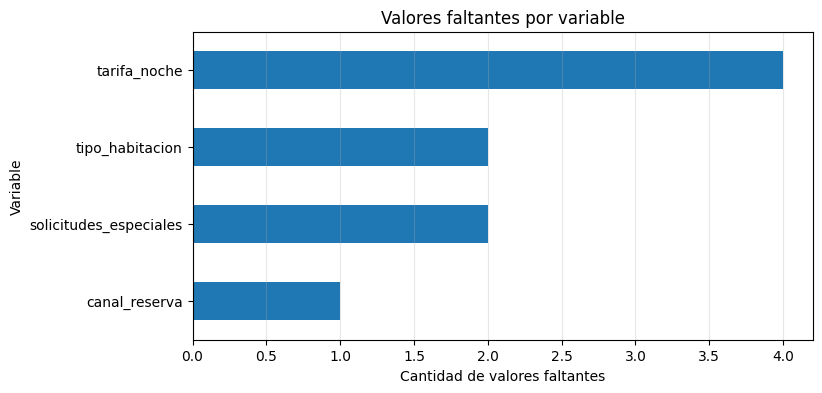

In [5]:
faltantes[faltantes > 0].sort_values().plot(
    kind="barh",
    figsize=(8, 4)
)

plt.title("Valores faltantes por variable")
plt.xlabel("Cantidad de valores faltantes")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.3)
plt.show()

El gráfico permite comparar rápidamente la magnitud del problema. En este ejemplo los faltantes son pocos, pero igualmente deben tratarse antes de usar muchos modelos de Machine Learning.

## 4. Construir `X` e `y` y separar antes de transformar

La variable objetivo es `cancelada`. El resto de las columnas formará `X`.

In [6]:
X = df.drop(columns="cancelada")
y = df["cancelada"]

print(f"Forma de X: {X.shape}")
print("Distribución de y:")
print(y.value_counts())

Forma de X: (36, 8)
Distribución de y:
cancelada
No    24
Sí    12
Name: count, dtype: int64


Tenemos 36 reservas: 24 no fueron canceladas y 12 sí. Usaremos una división 75/25 con estratificación para conservar aproximadamente esa distribución.

El orden es importante: separamos los datos originales antes de calcular medianas, categorías frecuentes o escalas.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (27, 8)
X_test:  (9, 8)


Quedaron 27 reservas para entrenamiento y 9 para prueba. A partir de este momento, cualquier transformación que necesite aprender valores se ajustará solamente con `X_train`.

## 5. Identificar columnas numéricas y categóricas

Cada grupo recibirá un tratamiento diferente.

In [8]:
columnas_numericas = [
    "dias_anticipacion",
    "noches",
    "huespedes",
    "tarifa_noche",
    "solicitudes_especiales",
]

columnas_categoricas = [
    "tipo_habitacion",
    "canal_reserva",
    "temporada",
]

print("Columnas numéricas:", columnas_numericas)
print("Columnas categóricas:", columnas_categoricas)

Columnas numéricas: ['dias_anticipacion', 'noches', 'huespedes', 'tarifa_noche', 'solicitudes_especiales']
Columnas categóricas: ['tipo_habitacion', 'canal_reserva', 'temporada']


Las variables numéricas serán imputadas con la mediana y luego escaladas. Las variables categóricas serán imputadas con la categoría más frecuente y después transformadas mediante One-Hot Encoding.

## 6. Crear los tratamientos para cada tipo de variable

Un `Pipeline` permite encadenar pasos en un orden determinado. Empezaremos con dos subpipelines: uno numérico y otro categórico.

In [9]:
transformador_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
])

transformador_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

En el bloque numérico, la imputación ocurre antes del escalado: el escalador necesita recibir valores completos. En el bloque categórico, la imputación ocurre antes de crear las columnas indicadoras.

El argumento `handle_unknown="ignore"` permite transformar más adelante casos que contengan una categoría no observada durante el entrenamiento. Esa categoría no obtiene una columna nueva; queda representada con ceros en las columnas conocidas de esa variable.

## 7. Combinar los tratamientos con `ColumnTransformer`

Ahora indicaremos qué transformador corresponde a cada grupo de columnas.

In [10]:
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas),
    ]
)

preprocesamiento

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputador',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalador',
                                                  StandardScaler())]),
                                 ['dias_anticipacion', 'noches', 'huespedes',
                                  'tarifa_noche', 'solicitudes_especiales']),
                                ('cat',
                                 Pipeline(steps=[('imputador',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['tipo_habitacion', 'canal_reserva',
                                  'temporada'])])

El objeto conserva en una sola estructura las decisiones de preparación. El bloque `num` actuará sobre las cinco variables numéricas y el bloque `cat`, sobre las tres categóricas.

Todavía no aprendió medianas, medias, desviaciones ni categorías. Eso ocurrirá al ajustarlo con los datos de entrenamiento.

## 8. Aprender con entrenamiento y transformar prueba

Usaremos `fit_transform()` sobre `X_train`: primero aprende las reglas y luego transforma esas filas. Para `X_test` usaremos solamente `transform()`, de modo que la prueba no enseñe nada nuevo.

In [11]:
X_train_preparado = preprocesamiento.fit_transform(X_train)
X_test_preparado = preprocesamiento.transform(X_test)

print(f"Entrenamiento original:   {X_train.shape}")
print(f"Entrenamiento preparado: {X_train_preparado.shape}")
print(f"Prueba original:          {X_test.shape}")
print(f"Prueba preparada:        {X_test_preparado.shape}")

Entrenamiento original:   (27, 8)
Entrenamiento preparado: (27, 14)
Prueba original:          (9, 8)
Prueba preparada:        (9, 14)


Las 8 columnas originales se transformaron en 14 columnas numéricas. La cantidad de filas no cambió: seguimos teniendo 27 reservas de entrenamiento y 9 de prueba.

El aumento de columnas se debe al One-Hot Encoding: cada categoría aprendida se convirtió en una columna indicadora.

En este dataset, el resultado fueron 14 columnas. En otros datasets, la cantidad final dependerá de cuántas variables categóricas haya y de cuántas categorías aprenda el codificador en el conjunto de entrenamiento.

In [12]:
nombres_columnas = preprocesamiento.get_feature_names_out()

X_train_preparado_df = pd.DataFrame(
    X_train_preparado,
    columns=nombres_columnas,
    index=X_train.index
)

X_train_preparado_df.head()

,num__dias_anticipacion,num__noches,num__huespedes,num__tarifa_noche,num__solicitudes_especiales,cat__tipo_habitacion_Estándar,cat__tipo_habitacion_Suite,cat__tipo_habitacion_Superior,cat__canal_reserva_Agencia,cat__canal_reserva_Teléfono,cat__canal_reserva_Web,cat__temporada_Alta,cat__temporada_Baja,cat__temporada_Media
3,-0.988371,-1.206501,-1.097666,-1.237677,-1.107823,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.849814,-0.635001,-1.097666,-0.980373,-1.107823,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
13,-0.018474,-0.063500,-0.075701,-0.079812,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
9,0.535752,0.508001,-0.075701,0.788587,0.000000,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
14,-1.043794,-1.206501,-1.097666,-1.462817,-1.107823,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


Todas las columnas preparadas son numéricas. Los nombres que comienzan con `num__` provienen del bloque numérico; los que comienzan con `cat__` fueron generados a partir de variables categóricas.

Los valores numéricos ya no conservan sus unidades originales porque fueron estandarizados. Las columnas categóricas aparecen como indicadores 0 y 1.

Podemos resumir las columnas numéricas después del escalado. `StandardScaler` busca que, en el conjunto con el que fue ajustado, cada variable tenga una media cercana a 0 y una desviación estándar cercana a 1.

In [13]:
columnas_numericas_transformadas = [
    f"num__{columna}" for columna in columnas_numericas
]

resumen_escalado = pd.DataFrame({
    "media": X_train_preparado_df[columnas_numericas_transformadas].mean(),
    "desviacion_estandar": X_train_preparado_df[columnas_numericas_transformadas].std(ddof=0),
}).round(3)

resumen_escalado

,media,desviacion_estandar
num__dias_anticipacion,0.0,1.0
num__noches,0.0,1.0
num__huespedes,0.0,1.0
num__tarifa_noche,0.0,1.0
num__solicitudes_especiales,0.0,1.0


Las medias quedaron prácticamente en 0 y las desviaciones estándar en 1. Esto no vuelve iguales a las variables ni elimina sus patrones: cambia su escala para que sus magnitudes sean comparables.

Estos valores se cumplen en entrenamiento porque el escalador aprendió de `X_train`. Al transformar prueba o casos nuevos, se aplican las mismas medias y desviaciones; no se vuelven a calcular.

Comprobemos que la preparación eliminó los faltantes sin perder filas.

In [14]:
print("Faltantes en X_train original:", int(X_train.isna().sum().sum()))
print("Faltantes después de preparar:", int(X_train_preparado_df.isna().sum().sum()))

Faltantes en X_train original: 5
Faltantes después de preparar: 0


El conjunto de entrenamiento tenía valores faltantes y la matriz preparada no contiene ninguno. Los imputadores completaron esas ausencias antes de aplicar las demás transformaciones.

## 9. Examinar qué aprendieron las transformaciones

El imputador numérico aprendió una mediana para cada variable usando exclusivamente `X_train`.

In [15]:
imputador_numerico_ajustado = (
    preprocesamiento.named_transformers_["num"]
    .named_steps["imputador"]
)

medianas_aprendidas = pd.Series(
    imputador_numerico_ajustado.statistics_,
    index=columnas_numericas,
    name="mediana_aprendida_con_train"
)

medianas_aprendidas

,mediana_aprendida_con_train
dias_anticipacion,30.0
noches,3.0
huespedes,2.0
tarifa_noche,99.0
solicitudes_especiales,1.0


Estas medianas forman parte del preprocesamiento aprendido. Cuando aparezca un faltante en prueba o en un caso nuevo, se usará el valor calculado con entrenamiento; no se volverá a calcular una mediana con los datos nuevos.

Podemos comparar esas medianas con las que habríamos obtenido usando el dataset completo. El objetivo no es elegir las que parezcan mejores, sino observar que son cálculos distintos.

In [16]:
comparacion_medianas = pd.DataFrame({
    "solo_entrenamiento": X_train[columnas_numericas].median(),
    "dataset_completo": X[columnas_numericas].median(),
})

comparacion_medianas

,solo_entrenamiento,dataset_completo
dias_anticipacion,30.0,26.5
noches,3.0,3.0
huespedes,2.0,2.0
tarifa_noche,99.0,93.5
solicitudes_especiales,1.0,1.0


Algunas medianas coinciden y otras cambian. Aunque la diferencia pueda ser pequeña, usar el dataset completo permitiría que la prueba influyera en la preparación. La validez del procedimiento depende del origen de la información, no de que el cambio resulte grande en este ejemplo.

El One-Hot Encoding también aprendió sus categorías a partir de `X_train`. Veamos qué columnas categóricas produjo.

In [17]:
columnas_onehot = [
    nombre for nombre in nombres_columnas
    if nombre.startswith("cat__")
]

columnas_onehot

['cat__tipo_habitacion_Estándar',
 'cat__tipo_habitacion_Suite',
 'cat__tipo_habitacion_Superior',
 'cat__canal_reserva_Agencia',
 'cat__canal_reserva_Teléfono',
 'cat__canal_reserva_Web',
 'cat__temporada_Alta',
 'cat__temporada_Baja',
 'cat__temporada_Media']

Cada categoría conocida durante el entrenamiento tiene su propia columna. No se asignaron números consecutivos a `Estándar`, `Superior` o `Suite`, por lo que no se introdujo un orden artificial entre ellas.

## 10. Transformar un caso con una categoría nueva

Supongamos que aparece una reserva realizada mediante una aplicación móvil, un canal que no estaba presente en el entrenamiento. También falta la tarifa por noche.

In [18]:
reserva_nueva = pd.DataFrame({
    "dias_anticipacion": [21],
    "noches": [3],
    "huespedes": [2],
    "tarifa_noche": [np.nan],
    "solicitudes_especiales": [1],
    "tipo_habitacion": ["Superior"],
    "canal_reserva": ["Aplicación móvil"],
    "temporada": ["Media"],
})

reserva_nueva

,dias_anticipacion,noches,huespedes,tarifa_noche,solicitudes_especiales,tipo_habitacion,canal_reserva,temporada
0,21,3,2,NaN,1,Superior,Aplicación móvil,Media


In [19]:
reserva_nueva_preparada = preprocesamiento.transform(reserva_nueva)

print(f"Forma del caso original: {reserva_nueva.shape}")
print(f"Forma del caso preparado: {reserva_nueva_preparada.shape}")
print("¿Contiene valores faltantes?:", np.isnan(reserva_nueva_preparada).any())

Forma del caso original: (1, 8)
Forma del caso preparado: (1, 14)
¿Contiene valores faltantes?: False


El caso se transformó sin errores y conserva las mismas 14 columnas que los conjuntos preparados. La tarifa faltante fue imputada con la mediana aprendida en entrenamiento.

Como `Aplicación móvil` era una categoría desconocida, `handle_unknown="ignore"` evitó crear una estructura incompatible. Esto resuelve el problema técnico de compatibilidad entre columnas, pero no significa que el modelo haya aprendido información específica sobre esa categoría nueva.

## 11. Integrar preprocesamiento y modelo en un `Pipeline`

Hasta ahora aplicamos el preprocesamiento de manera explícita para poder observar sus resultados. En un flujo de Machine Learning conviene unirlo con el modelo, asegurando que siempre reciba datos tratados de la misma manera.

Reutilizaremos KNN únicamente como pieza operativa, igual que en el primer recorrido completo. No analizaremos todavía sus vecinos, parámetros ni rendimiento.

In [20]:
flujo_completo = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", KNeighborsClassifier(n_neighbors=5)),
])

flujo_completo.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputador',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalador',
                                                                   StandardScaler())]),
                                                  ['dias_anticipacion',
                                                   'noches', 'huespedes',
                                                   'tarifa_noche',
                                                   'solicitudes_especiales']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputador',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['tipo_habitacion',
                                                   'canal_reserva',
                                                   'temporada'])])),
                ('clasificador', KNeighborsClassifier())])

Con una sola llamada a `.fit()`, el pipeline ajustó imputadores, escalador y codificador usando `X_train`, transformó esas filas y finalmente entrenó el clasificador con `y_train`.

La salida confirma que el flujo quedó ajustado, pero no nos dice si el modelo predice bien. Evaluar su rendimiento requiere herramientas que se desarrollarán en capítulos posteriores.

El mismo pipeline puede recibir datos originales. Internamente aplicará las transformaciones aprendidas antes de generar una predicción.

In [21]:
prediccion_nueva = flujo_completo.predict(reserva_nueva)

print("Predicción para la reserva nueva:", prediccion_nueva[0])

Predicción para la reserva nueva: No


El flujo produjo una categoría sin que tuviéramos que imputar, escalar ni codificar manualmente la nueva reserva. El resultado es solo una demostración técnica sobre un dataset pequeño y sintético; no debe interpretarse como un sistema real ni como evidencia de buen rendimiento.

## Actividad breve

Modificá algunos valores de `otra_reserva`, manteniendo las mismas columnas. Podés dejar un valor numérico como `np.nan` o escribir un canal nuevo.

In [22]:
otra_reserva = pd.DataFrame({
    "dias_anticipacion": [12],
    "noches": [2],
    "huespedes": [1],
    "tarifa_noche": [78],
    "solicitudes_especiales": [np.nan],
    "tipo_habitacion": ["Estándar"],
    "canal_reserva": ["Web"],
    "temporada": ["Baja"],
})

otra_reserva_preparada = flujo_completo.named_steps["preprocesamiento"].transform(otra_reserva)

print("Columnas esperadas:", X_train_preparado.shape[1])
print("Columnas obtenidas:", otra_reserva_preparada.shape[1])
print("Predicción:", flujo_completo.predict(otra_reserva)[0])

Columnas esperadas: 14
Columnas obtenidas: 14
Predicción: No


El caso nuevo mantiene la misma estructura que los datos usados para entrenar. Esa coherencia es una de las ventajas principales de conservar el preprocesamiento y el modelo dentro de un mismo pipeline.

## Cierre del cuaderno

En este cuaderno preparamos un dataset con variables numéricas, categóricas y valores faltantes. Primero separamos entrenamiento y prueba; después construimos transformaciones que aprendieron únicamente con `X_train` y se aplicaron sin reajustarse sobre `X_test`.

Usamos `SimpleImputer` para completar faltantes, `StandardScaler` para llevar variables numéricas a escalas comparables y `OneHotEncoder` para representar categorías nominales sin imponerles un orden. `ColumnTransformer` permitió aplicar cada tratamiento a las columnas correspondientes.

Finalmente, reunimos el preprocesamiento y un clasificador dentro de un `Pipeline`. El modelo utilizado fue solo una pieza operativa: el aprendizaje principal de este cuaderno es que preparar datos también implica aprender reglas, y esas reglas deben conservar la separación entre entrenamiento, prueba y casos nuevos.

## Para pensar

Antes de continuar, respondé con tus propias palabras:

1. ¿Por qué eliminar todas las filas con faltantes no es siempre una buena decisión?
2. ¿Qué diferencia hay entre imputar una variable numérica y aplicar One-Hot Encoding a una categórica?
3. ¿Por qué asignar 1, 2 y 3 a categorías nominales puede introducir información inexistente?
4. ¿Qué aprende `StandardScaler` durante `.fit()`?
5. ¿Por qué el preprocesamiento debe ajustarse solo con `X_train`?
6. ¿Qué funciones diferentes cumplen `ColumnTransformer` y `Pipeline`?